In [1]:
# 修改参数后，从此 cell 开始重新运行整个 notebook
DATA_START = "2021-01-01"
DATA_END = "2026-03-18"
SYMBOLS = ["510300.SS", "513100.SS", "518880.SS"]
NAMES = ["沪深300", "纳指100", "黄金"]
INITIAL_CASH = 100_000.0
PERIOD = 20
REBALANCE_DAYS = 10
ANNUAL_DAYS = 252
COMMISSION_RATE = 0.001
MINIMUM_COMMISSION = 5.0
STOP_LOSS = 0.05
MAR_ANNUAL = 0.0  # 已确认：索提诺最低可接受收益率为年化0%
DOWNLOAD_IF_MISSING = False
DRAWDOWN_THRESHOLD = -0.001  # 达到0.1%回撤才记录事件；恢复仍要求回到峰值
TOP_DRAWDOWN_EVENTS = 5
SENSITIVITY_VALUES = [10, 15, 20, 25, 30, 40]  # 六个离散交易日窗口


# Q5：五个策略与买入持有基准的总指标、自然年切片

比较等权、风险平价、RAM动量、RAM动量＋5%止损、风险平价＋5%止损，另加入初始等权买入后不调仓的基准。复用公共模块，每个策略独立回测，并统一扣除交易成本；不使用 q3/q4 保存的旧指标。

## 回测规则

- 沪深300、纳指100、黄金；初始10万元；五个主动策略使用20日指标窗口、每10个共同交易日调仓。日期和参数集中在首个 cell。
- 基准仅在首个共同交易日初始等权买入；随后不调仓、不追加买入、不卖出、不设止损。剩余现金一直保留，权重随价格漂移；回测末日按市值估值，不强制平仓，只扣初始买入手续费。
- 等权从首日建仓；风险平价与RAM需要21个价格算20个日对数收益，不使用2021年前的数据预热。保留前几章的启动规则，不人为对齐首次建仓日。
- 风险平价按日对数收益波动率倒数归一化（对角协方差假设）；RAM=日均对数收益/日对数收益样本标准差，非正分值剔除，正分值按比例归一化，全非正时现金100%。
- 整数股、先卖后买、买单预算手续费；每笔买卖佣金 max(成交额×0.001,5)。不含额外税费、滑点、现金利息。
- 沿用理想化 same_close：当日收盘信号、同一收盘价撮合。不模拟盘中触价。
- RAM与风险平价的止损策略均沿用q4：参考单只ETF当前持仓加权平均买入价（不含手续费），STOP全仓卖单；加仓更新均价，部分减仓不变，清仓重置。退出资金留现金，下一次计划调仓才可再入场，退出当天不重买。无止盈。两者使用同一个 STOP_LOSS 参数。

## 指标与年度边界

- 净值=资产/期初资产；总净值期初为1。年度期初资产取上一年最后净值，不在每年重置策略、持仓、预热或挂单；年度曲线各自将期初净值归一为1。
- 年度第一个收益包含跨年价格变化，不能在切片后直接 pct_change 丢掉首日。各年累计收益因子相乘，应等于全区间累计收益因子。
- 年化收益为 CAGR=(期末/期初)^(365.25/日历天数)−1。总区间使用实际首末观测日；中间完整自然年从上年12月31日至当年12月31日，非交易日沿用最近收盘估值。首末不足全年区间单独标注。
- 年化波动=日简单收益样本标准差×√252；简化夏普=日均简单收益/日简单收益样本标准差×√252，无风险利率为0。
- 最大回撤为正值，包含该切片期初资产作为峰值；年度回撤是年内局部回撤，不是全局回撤曲线的年度最小值。
- 卡玛=CAGR/最大回撤。
- MAR_日=(1+MAR_年)^(1/252)−1。下行偏差=sqrt(mean(min(日收益−MAR_日,0)^2))，均值分母为全部观测日，只让低于MAR的收益贡献风险；不是负收益子集的标准差。索提诺=mean(日收益−MAR_日)/下行偏差×√252。
- 无回撤、无下行偏差或无收益波动时，对应比率显示N/A，不伪造0或无穷大。

本次2026年截至3月18日，年化值是短区间折算，不是全年已实现收益。年度分析仍是历史样本内描述，不是样本外验证。

下行偏差参考：[PerformanceAnalytics 的默认 full 口径](https://raw.githubusercontent.com/braverock/PerformanceAnalytics/master/R/DownsideDeviation.R)。


In [2]:
from pathlib import Path
from dataclasses import asdict
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

root = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "backtest").is_dir() and (p / "pyproject.toml").is_file())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
from backtest import Account, SimBroker, Engine, DataFrameDataSource
from backtest.allocation import PeriodicAllocationStrategy, BuyAndHoldEqualWeightStrategy
from backtest.risk_controls import ProtectedAllocationStrategy
from backtest.performance import (
    METRIC_COLUMNS, performance_metrics, calendar_year_metrics,
    equity_returns, equity_drawdown,
    calendar_month_returns, monthly_return_statistics, drawdown_events,
)

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
OUTPUT_DIR = root / "q5" / "results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
start, end = pd.Timestamp(DATA_START), pd.Timestamp(DATA_END)
if start > end:
    raise ValueError("开始日期不能晚于结束日期")
if len(SYMBOLS) != len(NAMES) or len(set(SYMBOLS)) != len(SYMBOLS):
    raise ValueError("标的必须唯一，且与名称对应")
if not np.isfinite(MAR_ANNUAL) or MAR_ANNUAL <= -1:
    raise ValueError("MAR无效")

LABELS = dict(zip(METRIC_COLUMNS, [
    "净值", "累计收益率", "年化收益率", "年化波动率",
    "最大回撤", "简化夏普", "卡玛比率", "索提诺比率",
]))
PERCENT_METRICS = {"cumulative_return", "annualized_return", "annualized_volatility", "max_drawdown"}


In [3]:
def load_prices(symbol):
    candidates = []
    for folder in (root / "q3" / "data", root / "q4" / "data", root / "q5" / "data"):
        for path in sorted(folder.glob(f"{symbol}_*_adjusted.csv")):
            raw = pd.read_csv(path, index_col="Date", parse_dates=True).sort_index()
            # 这是区间边界的初筛；实际公共交易日仍由券商对齐。
            if raw.index.min() <= start + pd.Timedelta(days=7) and raw.index.max() >= end:
                candidates.append((path, raw))
    if candidates:
        path, raw = candidates[-1]
    elif DOWNLOAD_IF_MISSING:
        import yfinance as yf
        raw = yf.download(symbol, start=DATA_START,
            end=(end + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
            auto_adjust=True, multi_level_index=False, threads=False, progress=False)
        if raw.empty:
            raise RuntimeError(f"{symbol}: 下载失败且无有效缓存")
        folder = root / "q5" / "data"
        folder.mkdir(parents=True, exist_ok=True)
        raw.index.name = "Date"
        path = folder / f"{symbol}_{DATA_START}_{DATA_END}_adjusted.csv"
        raw.to_csv(path)
    else:
        raise RuntimeError(f"{symbol}: 缓存不覆盖日期，请检查日期或显式允许下载")
    frame = raw.loc[DATA_START:DATA_END, ["Open", "Close"]].copy()
    if frame.empty or frame.index.has_duplicates or frame.index.hasnans:
        raise ValueError(f"{symbol}: 日期为空、重复或无效")
    if not np.isfinite(frame.to_numpy()).all() or (frame <= 0).any().any():
        raise ValueError(f"{symbol}: 价格无效")
    assert frame.index.min() >= start and frame.index.max() <= end
    print(symbol, len(frame), frame.index.min().date(), frame.index.max().date(), path.name)
    return frame

frames = {s: load_prices(s) for s in SYMBOLS}
source = DataFrameDataSource(frames)


510300.SS 1258 2021-01-04 2026-03-18 510300.SS_2020-06-22_2026-03-18_adjusted.csv
513100.SS 1259 2021-01-04 2026-03-18 513100.SS_2020-06-22_2026-03-18_adjusted.csv
518880.SS 1258 2021-01-04 2026-03-18 518880.SS_2020-06-22_2026-03-18_adjusted.csv


In [4]:
strategy_specs = {
    "等权": ("equal", None),
    "风险平价": ("risk_parity", None),
    "RAM动量": ("ram", None),
    f"RAM动量 + {STOP_LOSS:.0%}止损": ("ram", STOP_LOSS),
    "基准（买入持有）": ("buy_hold_equal", None),
    f"风险平价 + {STOP_LOSS:.0%}止损": ("risk_parity", STOP_LOSS),
}
COLORS = dict(zip(strategy_specs, ["#4472C4", "#ED7D31", "#70AD47", "#C0504D", "#666666", "#8064A2"]))

def run_strategy(method, stop_loss=None, force_protected=False, *,
                 momentum_window=None, volatility_window=None):
    broker = SimBroker(source, DATA_START, DATA_END, SYMBOLS, execution_price="close",
                       commission_rate=COMMISSION_RATE, minimum_commission=MINIMUM_COMMISSION)
    if method == "buy_hold_equal":
        strategy = BuyAndHoldEqualWeightStrategy(SYMBOLS)
    elif stop_loss is None and not force_protected:
        strategy = PeriodicAllocationStrategy(method, SYMBOLS, PERIOD, REBALANCE_DAYS,
                                               momentum_window=momentum_window,
                                               volatility_window=volatility_window)
    else:
        strategy = ProtectedAllocationStrategy(method, SYMBOLS, PERIOD, REBALANCE_DAYS,
                                               stop_loss=stop_loss, momentum_window=momentum_window,
                                               volatility_window=volatility_window)
    engine = Engine(Account(INITIAL_CASH, SYMBOLS), broker, strategy,
                    ANNUAL_DAYS, signal_timing="same_close")
    ledger = engine.run()
    rejected = [r for r in broker.order_history if r.status == "REJECTED"]
    if rejected:
        raise RuntimeError(f"发现拒单，不能忽略：{rejected[:3]}")
    positions = ledger[[f"position_{s}" for s in SYMBOLS]].to_numpy()
    prices = ledger[[f"close_{s}" for s in SYMBOLS]].to_numpy()
    assert (ledger.cash >= -1e-8).all() and (positions >= 0).all()
    np.testing.assert_allclose(ledger.portfolio_value,
                               ledger.cash + (positions * prices).sum(axis=1), atol=1e-7)
    audit = pd.DataFrame(strategy.audit)
    assert (audit[SYMBOLS + ["CASH"]].sum(axis=1).sub(1).abs() <= 1e-6).all()
    expected_cash = INITIAL_CASH + sum(
        (1 if t.side == "SELL" else -1) * t.shares * t.price - t.commission
        for t in broker.trades)
    np.testing.assert_allclose(engine.account.cash, expected_cash, atol=1e-7)
    metrics = performance_metrics(ledger.portfolio_value, INITIAL_CASH,
                                 annual_trading_days=ANNUAL_DAYS, mar_annual=MAR_ANNUAL)
    annual = calendar_year_metrics(ledger.portfolio_value, INITIAL_CASH,
                                   annual_trading_days=ANNUAL_DAYS, mar_annual=MAR_ANNUAL)
    np.testing.assert_allclose(np.prod(1 + annual.cumulative_return),
                               ledger.portfolio_value.iloc[-1] / INITIAL_CASH, rtol=1e-10)
    np.testing.assert_allclose(
        metrics[["cumulative_return", "annualized_volatility", "max_drawdown", "simplified_sharpe"]],
        [engine.cumulative_return(), engine.annualized_volatility(),
         engine.max_drawdown(), engine.simplified_sharpe()], rtol=1e-10)
    return dict(engine=engine, ledger=ledger, metrics=metrics, annual=annual)

runs = {name: run_strategy(method, stop) for name, (method, stop) in strategy_specs.items()}
# 保护模块在不设阈值时必须与原RAM策略逐日结果完全一致。
ram_check = run_strategy("ram", force_protected=True)
pd.testing.assert_frame_equal(runs["RAM动量"]["ledger"], ram_check["ledger"])
del ram_check
benchmark = runs["基准（买入持有）"]
benchmark_ledger = benchmark["ledger"]
benchmark_trades = benchmark["engine"].broker.trades
assert benchmark_trades and all(t.side == "BUY" and t.date == benchmark_ledger.index[0] for t in benchmark_trades)
assert len(benchmark["engine"].strategy.audit) == 1
assert benchmark_ledger.cash.nunique() == 1
for symbol in SYMBOLS:
    assert benchmark_ledger[f"position_{symbol}"].nunique() == 1
pd.testing.assert_series_equal(benchmark_ledger.iloc[0], runs["等权"]["ledger"].iloc[0])
print("五个策略与买入持有基准回测完成；无止损保护策略与原RAM逐日一致；基准仅初始买入")


五个策略与买入持有基准回测完成；无止损保护策略与原RAM逐日一致；基准仅初始买入


## 总指标与年度指标

总指标中的净值是相对初始10万元的期末净值。年度指标中的净值是相对该年期初资产的期末净值，等于1＋该年累计收益率。

年度CSV另外保存全局年末净值、期初/期末资产和日历区间。年内最大回撤每年重新以期初资产为峰值，但持仓和订单从不按年重置。


In [5]:
total_metrics = pd.DataFrame({name: r["metrics"] for name, r in runs.items()}).T
total_metrics.index.name = "strategy"
annual_metrics = pd.concat({name: r["annual"] for name, r in runs.items()},
                           names=["strategy", "year"]).swaplevel().sort_index()

def show_metrics(table):
    # 指标为行、策略为列：总表与每年表都明确包含基准策略列。
    view = table[METRIC_COLUMNS].rename(columns=LABELS).T
    style = view.style.format("{:.4f}", na_rep="N/A")
    percent_rows = [LABELS[k] for k in METRIC_COLUMNS if k in PERCENT_METRICS]
    style = style.format("{:.2%}", subset=(percent_rows, list(view.columns)), na_rep="N/A")
    display(style)

print("总指标：")
show_metrics(total_metrics)
print("年度指标（2021与2026为区间首末切片；不完整年度见下表）：")
for year in annual_metrics.index.get_level_values("year").unique():
    print(f"{year}年：")
    show_metrics(annual_metrics.xs(year, level="year").reindex(list(strategy_specs)))
coverage = next(iter(runs.values()))["annual"][[
    "period_start", "period_end", "first_trading_date", "last_trading_date",
    "trading_days", "complete_calendar_year",
]]
display(coverage.rename(columns={
    "period_start": "期初估值日期", "period_end": "期末估值日期",
    "first_trading_date": "首个交易日", "last_trading_date": "末个交易日",
    "trading_days": "交易日数", "complete_calendar_year": "完整自然年",
}))
cost_table = pd.DataFrame({
    name: {
        "总手续费": sum(t.commission for t in r["engine"].broker.trades),
        "成交笔数": len(r["engine"].broker.trades),
        "止损成交次数": sum(e.status == "FILLED" and e.order.order_type == "STOP"
                             for e in r["engine"].broker.order_history),
        "首次建仓日": next((t.date for t in r["engine"].broker.trades if t.side == "BUY"), pd.NaT),
    } for name, r in runs.items()
}).T
print("费用与交易审计：")
display(cost_table)


总指标：


strategy,等权,风险平价,RAM动量,RAM动量 + 5%止损,基准（买入持有）,风险平价 + 5%止损
净值,1.8295,1.9873,2.3682,2.2889,1.9178,1.9844
累计收益率,82.95%,98.73%,136.82%,128.89%,91.78%,98.44%
年化收益率,12.32%,14.12%,18.04%,17.27%,13.34%,14.09%
年化波动率,12.42%,11.07%,15.29%,15.03%,12.99%,10.58%
最大回撤,16.76%,12.81%,21.65%,19.35%,17.26%,12.98%
简化夏普,1.0371,1.2989,1.2067,1.1792,1.0696,1.3511
卡玛比率,0.7349,1.1024,0.8331,0.8922,0.7732,1.0857
索提诺比率,1.4491,1.8587,1.7576,1.7209,1.4862,1.9662


年度指标（2021与2026为区间首末切片；不完整年度见下表）：
2021年：


strategy,等权,风险平价,RAM动量,RAM动量 + 5%止损,基准（买入持有）,风险平价 + 5%止损
净值,1.0330,1.0231,0.9520,0.9595,1.0400,1.0272
累计收益率,3.30%,2.31%,-4.80%,-4.05%,4.00%,2.72%
年化收益率,3.34%,2.33%,-4.85%,-4.09%,4.05%,2.75%
年化波动率,11.01%,9.67%,12.95%,12.30%,11.22%,9.28%
最大回撤,9.97%,9.36%,13.64%,12.68%,10.07%,7.91%
简化夏普,0.3607,0.2929,-0.3286,-0.2868,0.4186,0.3458
卡玛比率,0.3348,0.2493,-0.3557,-0.3229,0.4022,0.3475
索提诺比率,0.4942,0.4034,-0.4295,-0.3774,0.5736,0.4812


2022年：


...

2026年：


strategy,等权,风险平价,RAM动量,RAM动量 + 5%止损,基准（买入持有）,风险平价 + 5%止损
净值,1.0277,1.0173,1.0874,1.0874,1.0373,1.0173
累计收益率,2.77%,1.73%,8.74%,8.74%,3.73%,1.73%
年化收益率,13.83%,8.47%,48.81%,48.82%,18.98%,8.47%
年化波动率,21.37%,17.20%,33.40%,33.40%,25.13%,17.20%
最大回撤,8.18%,6.58%,12.37%,12.37%,9.84%,6.57%
简化夏普,0.7907,0.6192,1.5125,1.5125,0.9065,0.6191
卡玛比率,1.6905,1.2889,3.9473,3.9474,1.9294,1.2887
索提诺比率,1.0480,0.8377,2.1140,2.1140,1.1966,0.8376


,期初估值日期,期末估值日期,首个交易日,末个交易日,交易日数,完整自然年
year,,,,,,
2021,2021-01-04,2021-12-31,2021-01-04,2021-12-31,243,False
2022,2021-12-31,2022-12-31,2022-01-04,2022-12-30,242,True
2023,2022-12-31,2023-12-31,2023-01-03,2023-12-29,242,True
2024,2023-12-31,2024-12-31,2024-01-02,2024-12-31,242,True
2025,2024-12-31,2025-12-31,2025-01-02,2025-12-31,242,True
2026,2025-12-31,2026-03-18,2026-01-05,2026-03-18,47,False


费用与交易审计：


,总手续费,成交笔数,止损成交次数,首次建仓日
等权,1966.394748,376,0,2021-01-04 00:00:00
风险平价,3027.05045,372,0,2021-02-01 00:00:00
RAM动量,11375.973162,275,0,2021-02-01 00:00:00
RAM动量 + 5%止损,11469.71583,276,11,2021-02-01 00:00:00
基准（买入持有）,99.899249,3,0,2021-01-04 00:00:00
风险平价 + 5%止损,3899.442284,386,17,2021-02-01 00:00:00


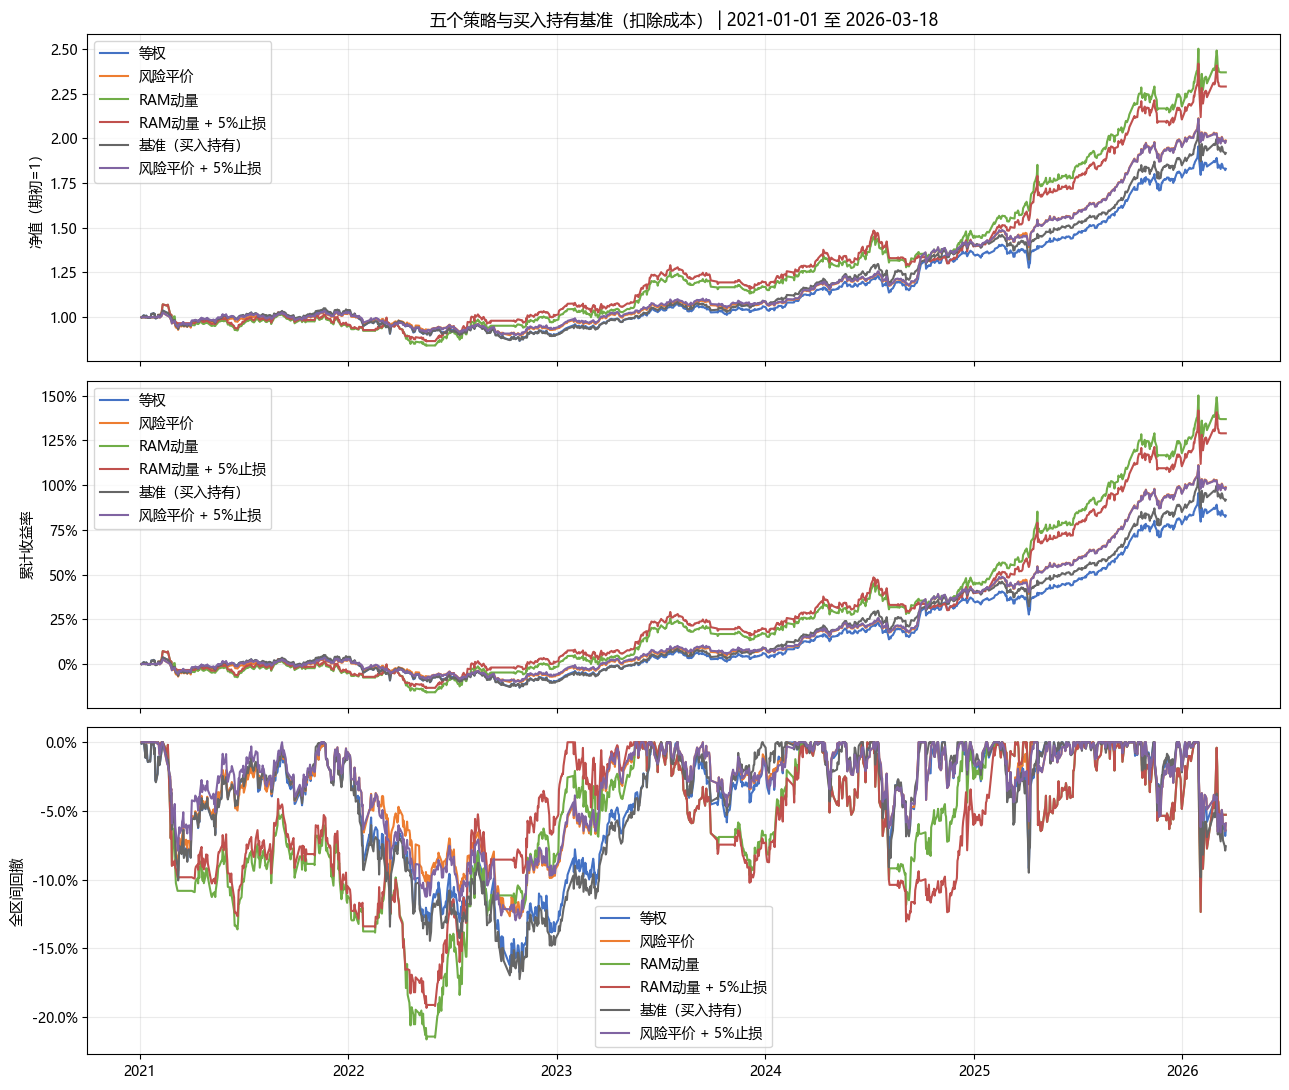

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
for name, r in runs.items():
    equity = r["ledger"].portfolio_value
    axes[0].plot(equity.index, equity / INITIAL_CASH, label=name, color=COLORS[name])
    axes[1].plot(equity.index, equity / INITIAL_CASH - 1, label=name, color=COLORS[name])
    axes[2].plot(equity.index, equity_drawdown(equity, INITIAL_CASH), label=name, color=COLORS[name])
axes[0].set_title(f"五个策略与买入持有基准（扣除成本） | {DATA_START} 至 {DATA_END}")
axes[0].set_ylabel("净值（期初=1）")
axes[1].set_ylabel("累计收益率")
axes[2].set_ylabel("全区间回撤")
for ax in axes:
    ax.grid(alpha=.25)
    ax.legend()
for ax in axes[1:]:
    ax.yaxis.set_major_formatter(PercentFormatter(1))
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_total_curves.png", dpi=150)
plt.show()
plt.close(fig)


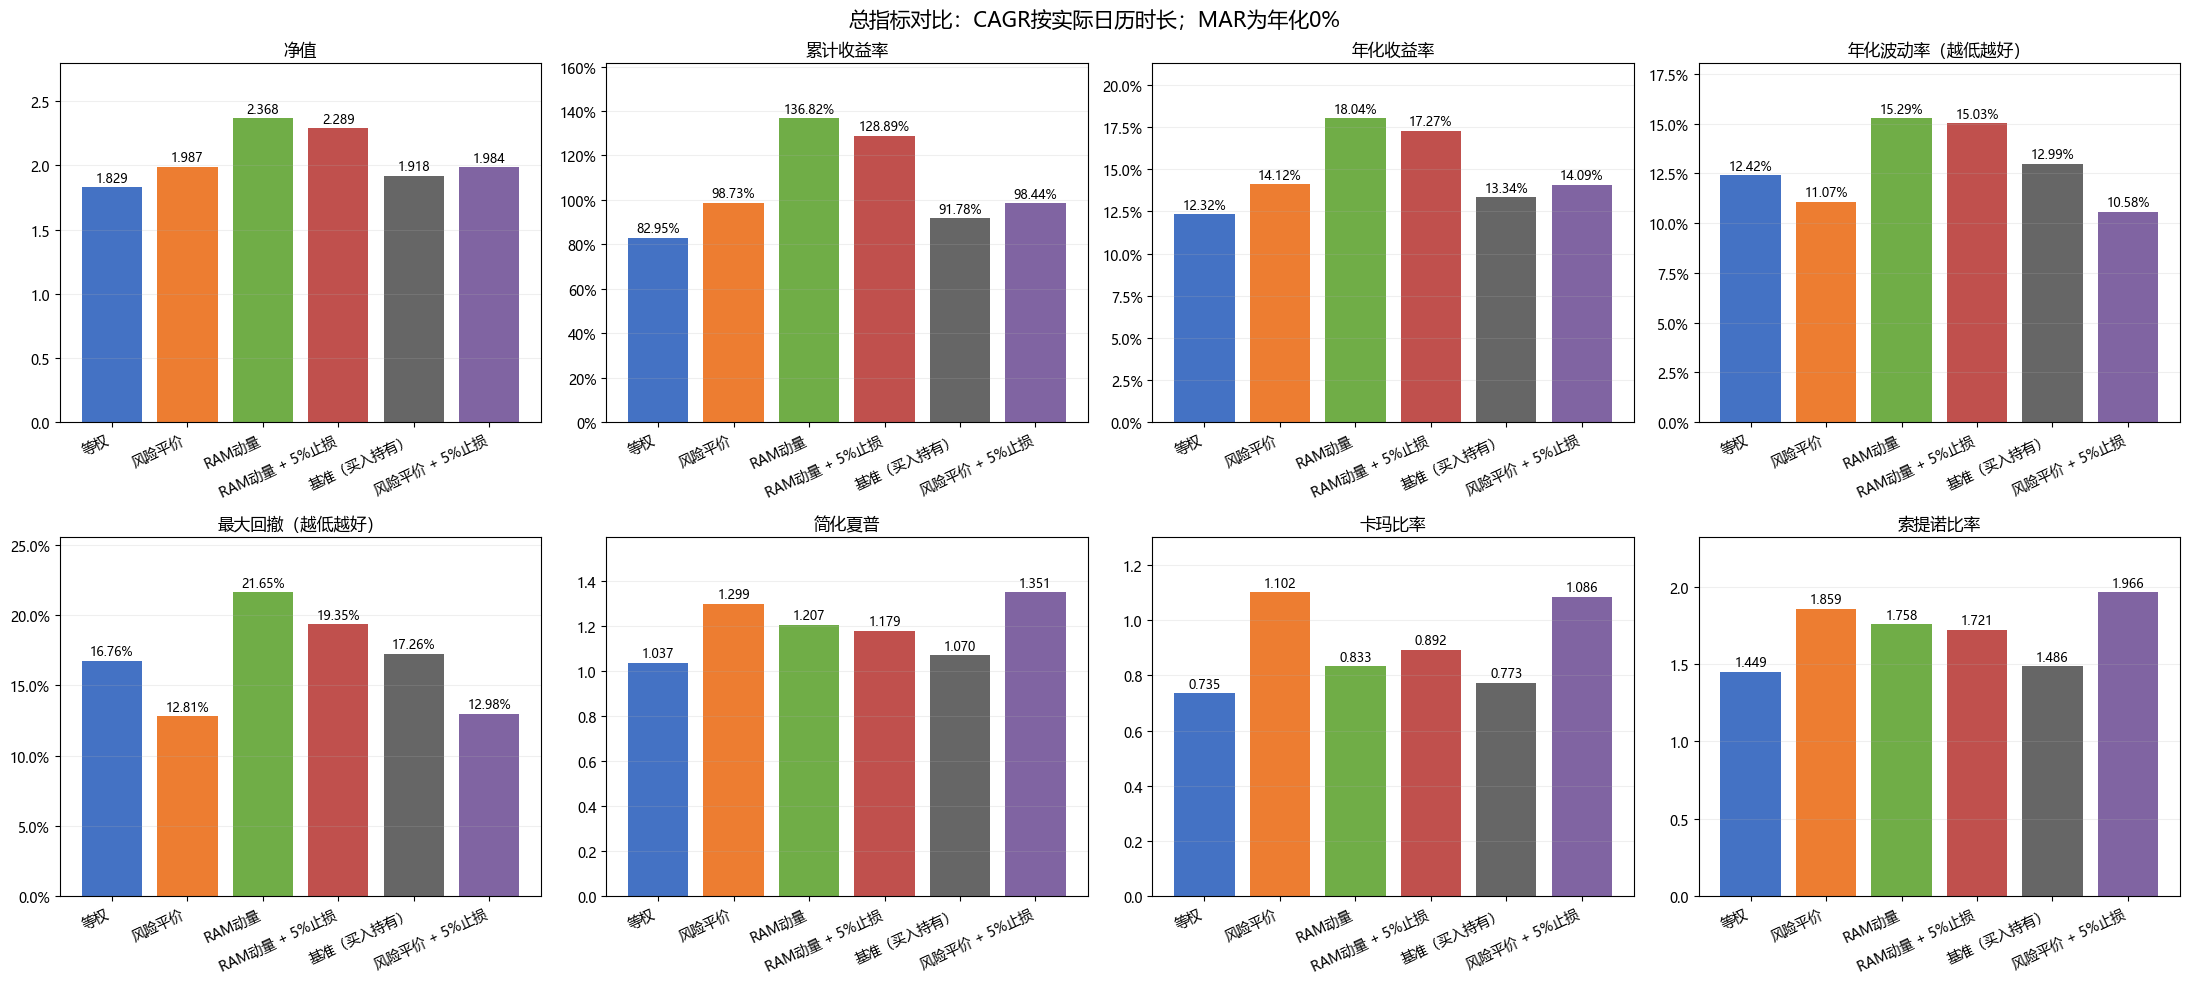

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for ax, metric in zip(axes.flat, METRIC_COLUMNS):
    values = total_metrics[metric]
    bars = ax.bar(range(len(values)), values, color=[COLORS[n] for n in values.index])
    ax.set_xticks(range(len(values)), values.index, rotation=25, ha="right")
    ax.set_title(LABELS[metric] + ("（越低越好）" if metric in {"annualized_volatility", "max_drawdown"} else ""))
    if metric in PERCENT_METRICS:
        ax.yaxis.set_major_formatter(PercentFormatter(1))
    for bar, value in zip(bars, values):
        if np.isfinite(value):
            label = f"{value:.2%}" if metric in PERCENT_METRICS else f"{value:.3f}"
            ax.annotate(label, (bar.get_x() + bar.get_width()/2, value),
                        xytext=(0, 4 if value >= 0 else -12), textcoords="offset points",
                        ha="center", fontsize=9)
    ax.axhline(0, color="gray", linewidth=.6)
    ax.grid(axis="y", alpha=.2)
    ax.margins(y=.18)
fig.suptitle("总指标对比：CAGR按实际日历时长；MAR为年化0%" if MAR_ANNUAL == 0
             else f"总指标对比：MAR={MAR_ANNUAL:.1%}", fontsize=15)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_total_metrics.png", dpi=150)
plt.show()
plt.close(fig)


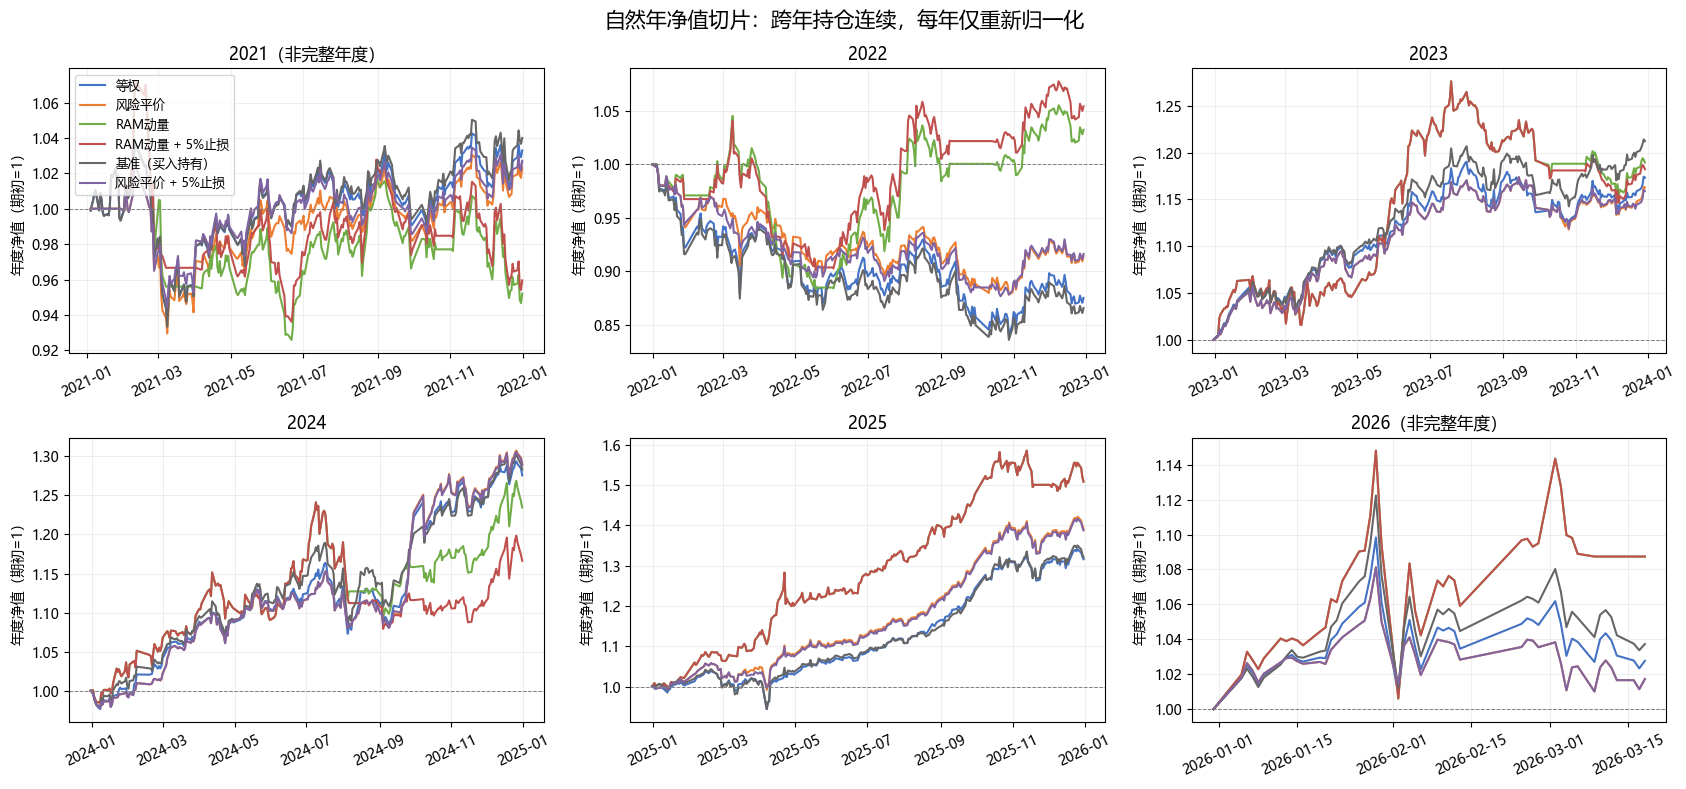

In [8]:
years = list(coverage.index)
columns = 3
rows = (len(years) + columns - 1) // columns
fig, axes = plt.subplots(rows, columns, figsize=(17, 4 * rows), squeeze=False)
for ax, year in zip(axes.flat, years):
    for name, r in runs.items():
        equity = r["ledger"].portfolio_value
        window = equity[equity.index.year == year]
        opening = r["annual"].loc[year, "opening_equity"]
        start_date = r["annual"].loc[year, "period_start"]
        curve = window / opening
        # 插入期初=1的基准点；若首日就是期初日期，不遮盖首日费用造成的净值变化。
        if start_date < curve.index[0]:
            curve = pd.concat([pd.Series([1.0], index=[start_date]), curve])
        ax.plot(curve.index, curve, label=name, color=COLORS[name])
    complete = bool(coverage.loc[year, "complete_calendar_year"])
    ax.set_title(str(year) + ("" if complete else "（非完整年度）"))
    ax.axhline(1, color="gray", linestyle="--", linewidth=.7)
    ax.set_ylabel("年度净值（期初=1）")
    ax.grid(alpha=.2)
    ax.tick_params(axis="x", rotation=25)
for ax in list(axes.flat)[len(years):]:
    ax.set_visible(False)
axes.flat[0].legend(fontsize=9)
fig.suptitle("自然年净值切片：跨年持仓连续，每年仅重新归一化", fontsize=15)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_yearly_nav.png", dpi=150)
plt.show()
plt.close(fig)


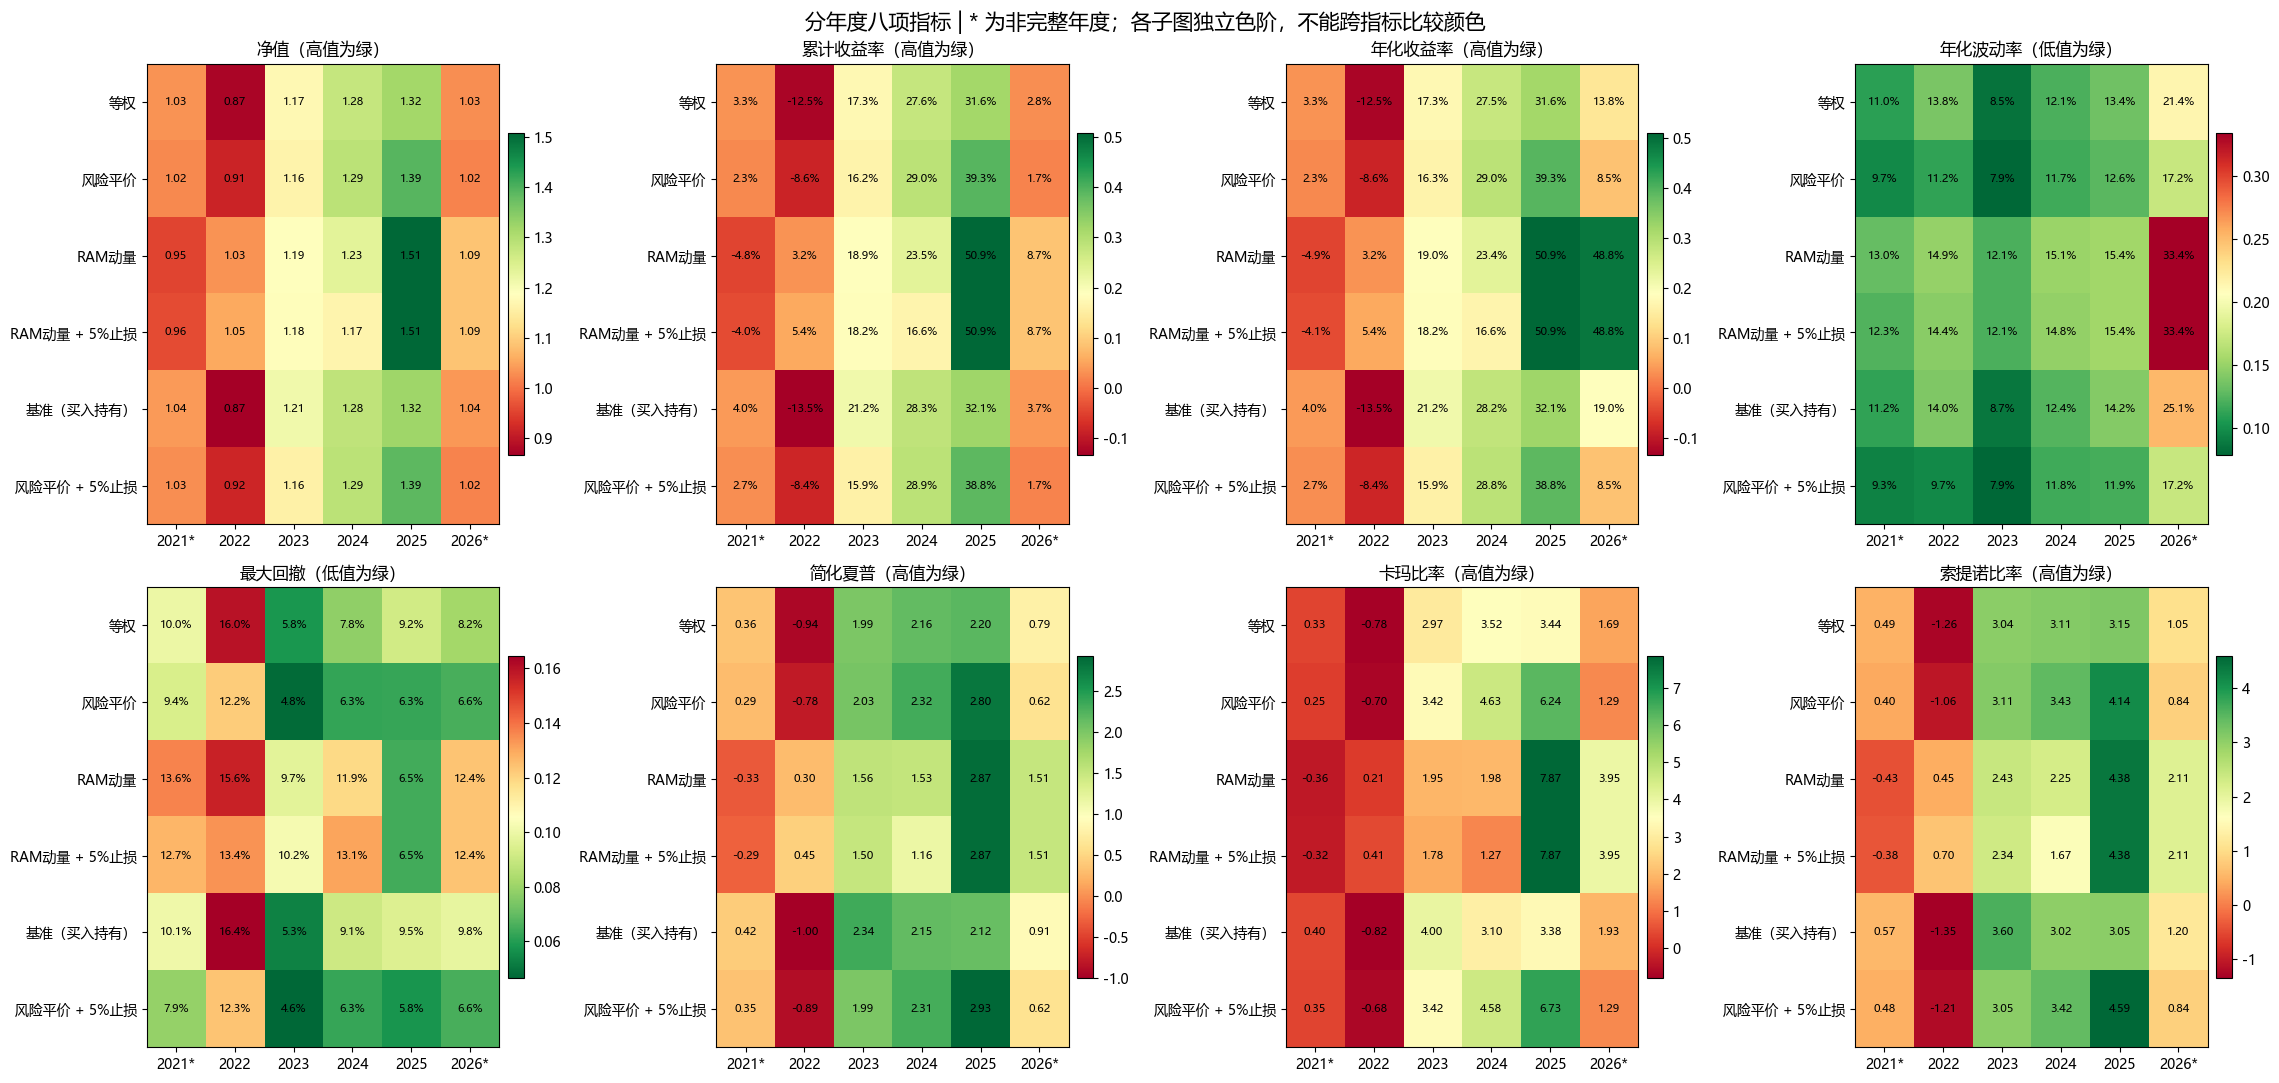

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(23, 11))
names = list(runs)
year_labels = [str(y) + ("*" if not coverage.loc[y, "complete_calendar_year"] else "")
               for y in years]
for ax, metric in zip(axes.flat, METRIC_COLUMNS):
    grid = np.array([[runs[name]["annual"].loc[y, metric] for y in years] for name in names])
    cmap = "RdYlGn_r" if metric in {"annualized_volatility", "max_drawdown"} else "RdYlGn"
    picture = ax.imshow(np.ma.masked_invalid(grid), aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(years)), year_labels)
    ax.set_yticks(range(len(names)), names)
    ax.set_title(LABELS[metric] + ("（低值为绿）" if metric in {"annualized_volatility", "max_drawdown"} else "（高值为绿）"))
    for i in range(len(names)):
        for j in range(len(years)):
            value = grid[i, j]
            label = "N/A" if not np.isfinite(value) else (
                f"{value:.1%}" if metric in PERCENT_METRICS else f"{value:.2f}")
            ax.text(j, i, label, ha="center", va="center", fontsize=8)
    fig.colorbar(picture, ax=ax, shrink=.7, pad=.02)
fig.suptitle("分年度八项指标 | * 为非完整年度；各子图独立色阶，不能跨指标比较颜色", fontsize=15)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "04_yearly_metrics.png", dpi=150)
plt.show()
plt.close(fig)


In [10]:
total_metrics.rename(columns=LABELS).to_csv(OUTPUT_DIR / "total_metrics.csv", encoding="utf-8-sig")
total_metrics.rename(columns=LABELS).T.to_csv(OUTPUT_DIR / "total_metrics_by_strategy.csv", encoding="utf-8-sig")
annual_metrics.rename(columns=LABELS).to_csv(OUTPUT_DIR / "annual_metrics.csv", encoding="utf-8-sig")
annual_columns = pd.concat({year: annual_metrics.xs(year, level="year").reindex(list(strategy_specs))[METRIC_COLUMNS].rename(columns=LABELS).T
                            for year in annual_metrics.index.get_level_values("year").unique()}, names=["year", "metric"])
annual_columns.to_csv(OUTPUT_DIR / "annual_metrics_by_strategy.csv", encoding="utf-8-sig")
cost_table.to_csv(OUTPUT_DIR / "trading_costs.csv", encoding="utf-8-sig")
for number, (name, r) in enumerate(runs.items()):
    r["ledger"].to_csv(OUTPUT_DIR / f"strategy_{number}_ledger.csv")
    pd.DataFrame([asdict(t) for t in r["engine"].broker.trades]).to_csv(
        OUTPUT_DIR / f"strategy_{number}_trades.csv", index=False)
metadata = {
    "data_start": DATA_START, "data_end": DATA_END,
    "actual_start": str(next(iter(runs.values()))["ledger"].index[0].date()),
    "actual_end": str(next(iter(runs.values()))["ledger"].index[-1].date()),
    "symbols": SYMBOLS, "initial_cash": INITIAL_CASH,
    "period": PERIOD, "rebalance_days": REBALANCE_DAYS,
    "commission_rate": COMMISSION_RATE, "minimum_commission": MINIMUM_COMMISSION,
    "stop_loss": STOP_LOSS, "mar_annual": MAR_ANNUAL, "annual_trading_days": ANNUAL_DAYS,
    "execution": "same_close", "cagr_basis": "elapsed calendar days / 365.25",
    "yearly_rule": "continuous holdings; previous-year close as opening capital",
    "sortino_denominator": "full-series root mean square of below-MAR excess returns",
    "strategies": {str(i): name for i, name in enumerate(runs)},
    "benchmark": "equal allocation at first close only; no rebalance or liquidation",
}
(OUTPUT_DIR / "configuration.json").write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")

# 不以一个指标强行宣布总体最好；列出各指标的样本内优胜者。
winners = {LABELS[k]: (total_metrics[k].idxmin() if k in
           {"annualized_volatility", "max_drawdown"} else total_metrics[k].idxmax())
           for k in METRIC_COLUMNS}
display(pd.Series(winners, name="该指标样本内优胜策略").to_frame())
print("年度收益因子乘积与总收益一致；所有策略无拒单、无负持仓，手续费账目核对通过。")
print("结果目录：", OUTPUT_DIR)
print("2026不是完整年度；历史指标对比不等于样本外验证或未来收益保证。")


,该指标样本内优胜策略
净值,RAM动量
累计收益率,RAM动量
年化收益率,RAM动量
年化波动率,风险平价 + 5%止损
最大回撤,风险平价
简化夏普,风险平价 + 5%止损
卡玛比率,风险平价
索提诺比率,风险平价 + 5%止损


年度收益因子乘积与总收益一致；所有策略无拒单、无负持仓，手续费账目核对通过。
结果目录： D:\proj\xquant\xquant-learning-sxl\q5\results
2026不是完整年度；历史指标对比不等于样本外验证或未来收益保证。


## 月度收益分布：五个策略 + 买入持有基准

沿用上面的同一条扣费后账户净值，不重新回测、不清仓、不重置持仓。

- 自然月收益 = 当月最后一次账户净值 / 上月最后一次账户净值 − 1；首月以初始本金为分母，包含首次交易成本。
- 首末月即使不完整也保留，不年化、不外推；末月仅用区间末日前已观测的数据。覆盖日期见下表。
- 盈利月严格大于0，亏损月严格小于0，零收益月计入总月数但不计入盈亏月，并打断连续盈亏。
- 平均盈利/亏损为相应月份的条件均值；盈亏比为平均盈利月收益 / 平均亏损月收益绝对值。
- Profit Factor按**月收益率之和**计算：正月收益率合计 / 负月收益率合计绝对值，不是交易级Profit Factor，也不是盈利金额之比。
- 无盈利或亏损样本导致均值/分母不存在时显示N/A；月收益因子的乘积应等于总净值。


In [11]:
monthly_returns = pd.DataFrame({
    name: calendar_month_returns(r["ledger"].portfolio_value, INITIAL_CASH)
    for name, r in runs.items()
})
monthly_stats = pd.DataFrame({
    name: monthly_return_statistics(monthly_returns[name]) for name in runs
}).T
monthly_stats.index.name = "strategy"
MONTHLY_LABELS = {
    "total_months": "总月数", "winning_months": "盈利月数",
    "losing_months": "亏损月数", "flat_months": "零收益月数",
    "win_rate": "胜率（盈利月/总月）",
    "average_winning_return": "平均盈利月收益",
    "average_losing_return": "平均亏损月收益",
    "payoff_ratio": "盈亏比", "profit_factor": "Profit Factor",
    "best_month": "最好月收益", "worst_month": "最差月收益",
    "longest_winning_streak": "最长连续盈利月数",
    "longest_losing_streak": "最长连续亏损月数",
}
monthly_percent = ["win_rate", "average_winning_return", "average_losing_return",
                   "best_month", "worst_month"]
monthly_counts = ["total_months", "winning_months", "losing_months", "flat_months",
                  "longest_winning_streak", "longest_losing_streak"]
view = monthly_stats.rename(columns=MONTHLY_LABELS).T
style = view.style.format("{:.3f}", na_rep="N/A")
style = style.format("{:.2%}", subset=([MONTHLY_LABELS[k] for k in monthly_percent],
                                      list(view.columns)), na_rep="N/A")
style = style.format("{:.0f}", subset=([MONTHLY_LABELS[k] for k in monthly_counts],
                                      list(view.columns)), na_rep="N/A")
display(style)

# 同一数据日历：只列出首末月覆盖情况，不把休市日误判为缺失。
reference = next(iter(runs.values()))["ledger"]
month_groups = reference.groupby(reference.index.to_period("M"))
monthly_coverage = pd.DataFrame({
    "首个估值日": month_groups.apply(lambda g: g.index[0]),
    "末个估值日": month_groups.apply(lambda g: g.index[-1]),
    "估值日数": month_groups.size(),
})
monthly_coverage["边界说明"] = ""
first_month, last_month = monthly_returns.index[0], monthly_returns.index[-1]
monthly_coverage.loc[first_month, "边界说明"] = "首月以初始本金计算，含建仓成本"
if min(end, reference.index[-1]) < last_month.end_time.normalize():
    monthly_coverage.loc[last_month, "边界说明"] += "；末月截至区间末日（非完整月）"
display(monthly_coverage.loc[~monthly_coverage["边界说明"].eq("")])

for name in runs:
    assert np.isclose(np.prod(1 + monthly_returns[name]), total_metrics.loc[name, "nav"])
assert (monthly_stats.total_months == monthly_stats.winning_months
        + monthly_stats.losing_months + monthly_stats.flat_months).all()
print("月收益因子与总净值核对通过；月统计已包含五个策略和基准。")


strategy,等权,风险平价,RAM动量,RAM动量 + 5%止损,基准（买入持有）,风险平价 + 5%止损
总月数,63,63,63,63,63,63
盈利月数,40,39,43,42,41,38
亏损月数,23,23,19,20,22,24
零收益月数,0,1,1,1,0,1
胜率（盈利月/总月）,63.49%,61.90%,68.25%,66.67%,65.08%,60.32%
平均盈利月收益,2.55%,2.78%,3.24%,3.20%,2.62%,2.78%
平均亏损月收益,-1.68%,-1.61%,-2.56%,-2.37%,-1.79%,-1.44%
盈亏比,1.513,1.727,1.266,1.351,1.460,1.938
Profit Factor,2.631,2.928,2.866,2.838,2.721,3.069
最好月收益,9.49%,10.83%,9.42%,9.42%,8.04%,10.71%


,首个估值日,末个估值日,估值日数,边界说明
Date,,,,
2021-01,2021-01-04,2021-01-29,20,首月以初始本金计算，含建仓成本
2026-03,2026-03-02,2026-03-18,13,；末月截至区间末日（非完整月）


月收益因子与总净值核对通过；月统计已包含五个策略和基准。


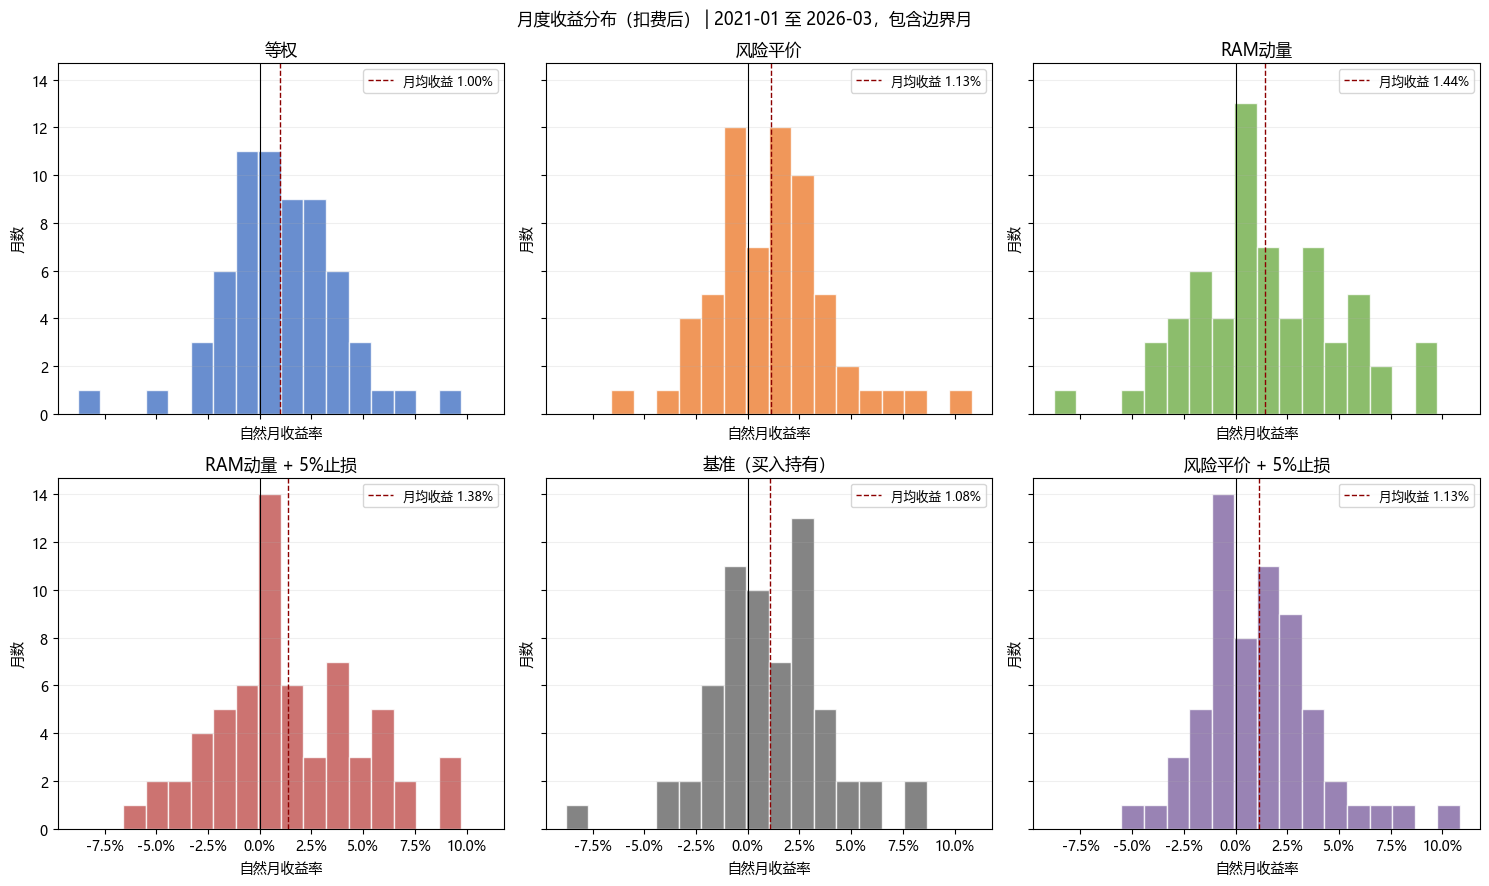

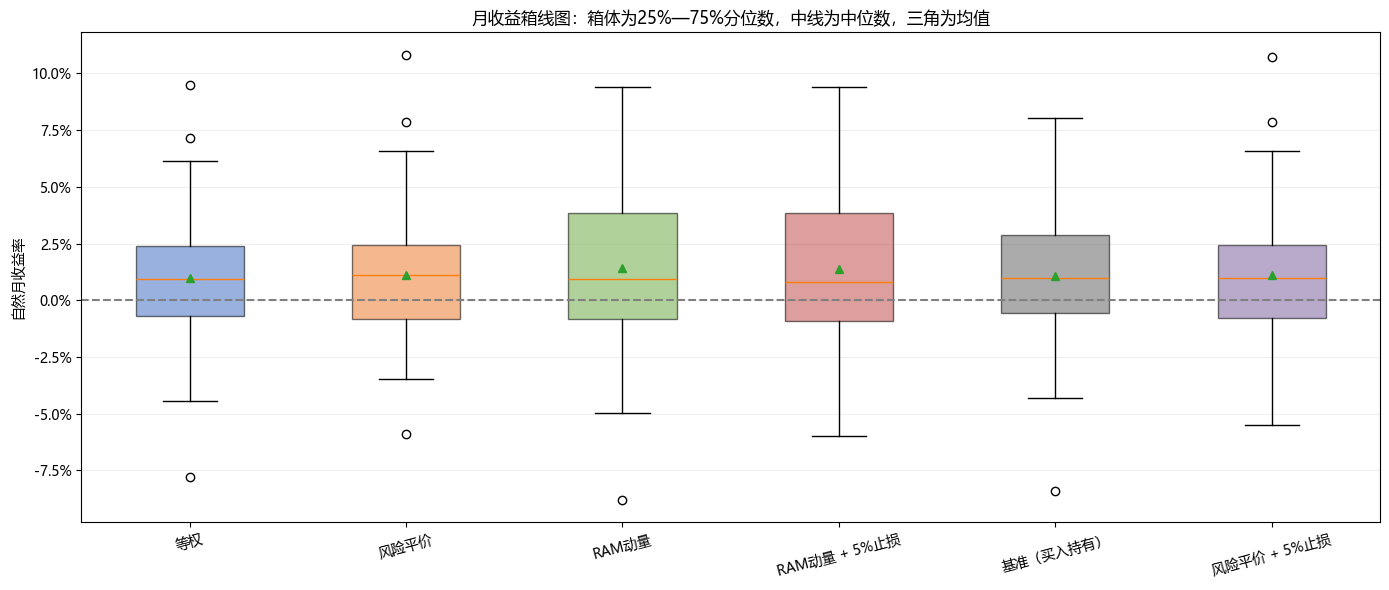

In [12]:
# 共同分箱和坐标轴，便于直接比较六个策略的分布。
bounds = monthly_returns.to_numpy()
low, high = min(float(bounds.min()), 0), max(float(bounds.max()), 0)
if low == high:
    low, high = -.01, .01
bins = np.linspace(low, high, 19)
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
for ax, name in zip(axes.flat, runs):
    returns = monthly_returns[name]
    ax.hist(returns, bins=bins, color=COLORS[name], alpha=.8, edgecolor="white")
    ax.axvline(0, color="black", linewidth=.8)
    ax.axvline(returns.mean(), color="darkred", linestyle="--", linewidth=1,
               label=f"月均收益 {returns.mean():.2%}")
    ax.set_title(name)
    ax.set_xlabel("自然月收益率")
    ax.set_ylabel("月数")
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(axis="y", alpha=.2)
    ax.legend(fontsize=9)
fig.suptitle(f"月度收益分布（扣费后） | {first_month} 至 {last_month}，包含边界月")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "05_monthly_distribution.png", dpi=150)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(14, 6))
boxes = ax.boxplot([monthly_returns[n].to_numpy() for n in runs],
                   tick_labels=list(runs), patch_artist=True, showmeans=True)
for box, name in zip(boxes["boxes"], runs):
    box.set_facecolor(COLORS[name])
    box.set_alpha(.55)
ax.axhline(0, color="gray", linestyle="--")
ax.set_title("月收益箱线图：箱体为25%—75%分位数，中线为中位数，三角为均值")
ax.set_ylabel("自然月收益率")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=.2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "06_monthly_boxplot.png", dpi=150)
plt.show()
plt.close(fig)


## 回撤事件与水下曲线

水下曲线 = 当日净值 / 截至当日的历史最高净值 − 1，初始本金也参与峰值计算。

**事件筛选阈值为−0.001（−0.1%），不是−0.001%。** 一次事件从最近的前峰日期开始，在首次达到阈值时被纳入统计，直到净值回到或超过该峰值才结束；中途回撤变浅不拆分事件。最低点取首次达到该事件最深回撤的日期。

- 按回撤深度从最负到最浅，显示每个策略前5次；不足5次则只显示真实事件。
- 下跌天数 = 最低点日期 − 开始日期；恢复天数 = 恢复日期 − 最低点日期，均为**自然日**，不是交易日。
- 尚未恢复的事件参与深度排名，恢复时间与恢复天数保留空值，显示“未恢复”；末次观测日不冒充恢复日。
- 图中数字对应前5事件排名；额外保留基准面板，方便比较。


In [13]:
if isinstance(TOP_DRAWDOWN_EVENTS, bool) or not isinstance(TOP_DRAWDOWN_EVENTS, int) or TOP_DRAWDOWN_EVENTS <= 0:
    raise ValueError("TOP_DRAWDOWN_EVENTS必须为正整数")
events_by_strategy, top_events_by_strategy = {}, {}
EVENT_LABELS = {
    "start_date": "开始时间（前峰）", "trigger_date": "首次达到阈值时间",
    "trough_date": "最低点时间", "recovery_date": "恢复时间",
    "depth": "回撤深度", "decline_days": "下跌天数（自然日）",
    "recovery_days": "恢复天数（自然日）", "recovered": "已恢复",
    "last_observed_date": "事件末次观测日",
}
for name, r in runs.items():
    equity = r["ledger"].portfolio_value
    events = drawdown_events(equity, INITIAL_CASH, threshold=DRAWDOWN_THRESHOLD)
    events.index = pd.RangeIndex(1, len(events) + 1, name="event_number")
    top = events.sort_values(["depth", "start_date"], kind="stable").head(TOP_DRAWDOWN_EVENTS).copy()
    top.insert(0, "rank", range(1, len(top) + 1))
    events_by_strategy[name], top_events_by_strategy[name] = events, top
    dd = equity_drawdown(equity, INITIAL_CASH)
    if not events.empty:
        assert np.isclose(events.depth.min(), dd.min())
        assert (events.depth <= DRAWDOWN_THRESHOLD).all()
        assert (events.start_date <= events.trigger_date).all()
        assert (events.trigger_date <= events.trough_date).all()
        assert (events.trough_date <= events.last_observed_date).all()
        recovered = events[events.recovered]
        assert (recovered.recovery_date >= recovered.trough_date).all()
        assert events.loc[~events.recovered, "recovery_date"].isna().all()
        assert events.loc[~events.recovered, "recovery_days"].isna().all()
    else:
        assert dd.min() > DRAWDOWN_THRESHOLD
    print(f"{name}：共{len(events)}次达阈值事件，未恢复{int((~events.recovered).sum())}次")
    if top.empty:
        print("无符合阈值的回撤事件")
        continue
    view = top[["rank", "start_date", "trough_date", "recovery_date", "depth",
                "decline_days", "recovery_days", "recovered"]].copy()
    for col in ["start_date", "trough_date", "recovery_date"]:
        view[col] = pd.to_datetime(view[col]).dt.strftime("%Y-%m-%d").fillna("未恢复")
    for col in ["decline_days", "recovery_days"]:
        view[col] = view[col].astype("Int64")
    view = view.set_index("rank").rename(columns=EVENT_LABELS)
    view.index.name = "深度排名"
    display(view.style.format({"回撤深度": "{:.2%}"}, na_rep="—"))
all_drawdown_events = pd.concat(events_by_strategy, names=["strategy", "event_number"])
top_drawdown_events = pd.concat(top_events_by_strategy, names=["strategy", "event_number"])
print("事件最深回撤与原有最大回撤指标核对通过。")


等权：共56次达阈值事件，未恢复1次


,开始时间（前峰）,最低点时间,恢复时间,回撤深度,下跌天数（自然日）,恢复天数（自然日）,已恢复
深度排名,,,,,,,
1,2021-11-19,2022-10-28,2023-06-16,-16.76%,343,231,True
2,2021-02-10,2021-03-09,2021-11-19,-9.97%,27,255,True
3,2025-02-19,2025-04-07,2025-05-06,-9.19%,47,29,True
4,2026-01-29,2026-02-02,未恢复,-8.18%,4,—,False
5,2024-07-17,2024-08-05,2024-09-26,-7.80%,19,52,True


风险平价：共55次达阈值事件，未恢复1次


,开始时间（前峰）,最低点时间,恢复时间,回撤深度,下跌天数（自然日）,恢复天数（自然日）,已恢复
深度排名,,,,,,,
1,2021-11-19,2022-10-28,2023-05-19,-12.81%,343,203,True
2,2021-02-10,2021-03-09,2021-11-19,-9.36%,27,255,True
3,2026-01-29,2026-03-09,未恢复,-6.58%,39,—,False
4,2025-02-19,2025-04-07,2025-04-14,-6.29%,47,7,True
5,2024-07-17,2024-09-09,2024-09-26,-6.25%,54,17,True


RAM动量：共48次达阈值事件，未恢复1次


...

基准（买入持有）：共65次达阈值事件，未恢复1次


,开始时间（前峰）,最低点时间,恢复时间,回撤深度,下跌天数（自然日）,恢复天数（自然日）,已恢复
深度排名,,,,,,,
1,2021-11-19,2022-10-28,2023-06-16,-17.26%,343,231,True
2,2021-02-10,2021-03-09,2021-11-15,-10.07%,27,251,True
3,2026-01-29,2026-02-02,未恢复,-9.84%,4,—,False
4,2025-02-19,2025-04-07,2025-04-22,-9.50%,47,15,True
5,2024-07-17,2024-08-05,2024-09-30,-9.11%,19,56,True


风险平价 + 5%止损：共55次达阈值事件，未恢复1次


,开始时间（前峰）,最低点时间,恢复时间,回撤深度,下跌天数（自然日）,恢复天数（自然日）,已恢复
深度排名,,,,,,,
1,2021-11-19,2022-10-21,2023-05-19,-12.98%,336,210,True
2,2021-02-10,2021-03-09,2021-09-07,-7.91%,27,182,True
3,2026-01-29,2026-03-09,未恢复,-6.57%,39,—,False
4,2024-07-17,2024-09-09,2024-09-26,-6.28%,54,17,True
5,2025-02-19,2025-04-07,2025-04-16,-5.76%,47,9,True


事件最深回撤与原有最大回撤指标核对通过。


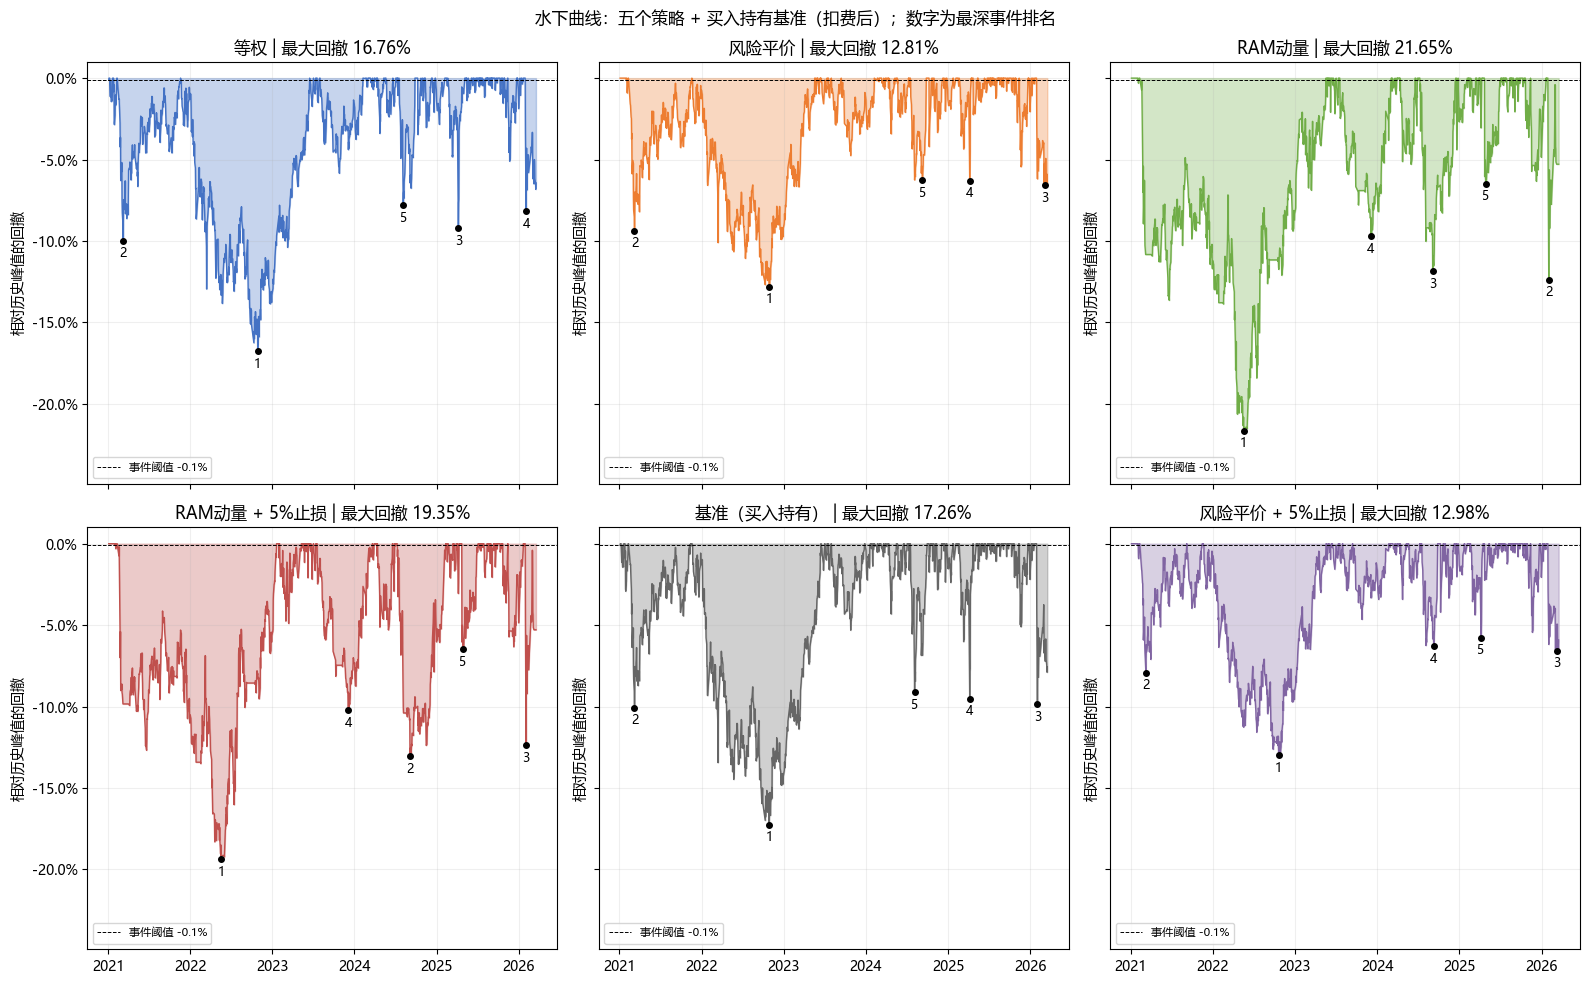

In [14]:
from matplotlib.dates import YearLocator, DateFormatter

underwater = pd.DataFrame({
    name: equity_drawdown(r["ledger"].portfolio_value, INITIAL_CASH)
    for name, r in runs.items()
})
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)
lower = min(float(underwater.min().min()) * 1.15, DRAWDOWN_THRESHOLD * 2, -.01)
for ax, name in zip(axes.flat, runs):
    dd = underwater[name]
    ax.plot(dd.index, dd, color=COLORS[name], linewidth=1)
    ax.fill_between(dd.index, dd.to_numpy(), 0, color=COLORS[name], alpha=.3)
    ax.axhline(DRAWDOWN_THRESHOLD, color="black", linestyle="--", linewidth=.7,
               label=f"事件阈值 {DRAWDOWN_THRESHOLD:.1%}")
    for _, event in top_events_by_strategy[name].iterrows():
        ax.scatter(event.trough_date, event.depth, color="black", s=16, zorder=4)
        ax.annotate(str(int(event["rank"])), (event.trough_date, event.depth),
                    xytext=(0, -12), textcoords="offset points", ha="center", fontsize=9)
    ax.set_title(f"{name} | 最大回撤 {-dd.min():.2%}")
    ax.set_ylim(lower, .01)
    ax.set_ylabel("相对历史峰值的回撤")
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.xaxis.set_major_locator(YearLocator())
    ax.xaxis.set_major_formatter(DateFormatter("%Y"))
    ax.grid(alpha=.2)
    ax.legend(loc="lower left", fontsize=8)
fig.suptitle("水下曲线：五个策略 + 买入持有基准（扣费后）；数字为最深事件排名")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "07_underwater.png", dpi=150)
plt.show()
plt.close(fig)


In [15]:
monthly_returns.to_csv(OUTPUT_DIR / "monthly_returns.csv", encoding="utf-8-sig")
monthly_stats.rename(columns=MONTHLY_LABELS).to_csv(
    OUTPUT_DIR / "monthly_statistics.csv", encoding="utf-8-sig")
monthly_stats.rename(columns=MONTHLY_LABELS).T.to_csv(
    OUTPUT_DIR / "monthly_statistics_by_strategy.csv", encoding="utf-8-sig")
monthly_coverage.to_csv(OUTPUT_DIR / "monthly_coverage.csv", encoding="utf-8-sig")
all_drawdown_events.rename(columns=EVENT_LABELS).to_csv(
    OUTPUT_DIR / "all_drawdown_events.csv", encoding="utf-8-sig")
top_drawdown_events.rename(columns={**EVENT_LABELS, "rank": "深度排名"}).to_csv(
    OUTPUT_DIR / "top5_drawdown_events.csv", encoding="utf-8-sig")
underwater.to_csv(OUTPUT_DIR / "underwater.csv", encoding="utf-8-sig")
metadata.update({
    "monthly_rule": "month-end equity / prior month-end - 1; first opens at initial cash; include partial boundary months",
    "monthly_profit_factor": "sum positive monthly return rates / abs(sum negative monthly return rates)",
    "zero_month_rule": "included in total; neither win nor loss; breaks streaks",
    "drawdown_threshold": DRAWDOWN_THRESHOLD,
    "top_drawdown_events": TOP_DRAWDOWN_EVENTS,
    "drawdown_start": "last pre-dip high-water mark; opening cash dated at first observation",
    "drawdown_recovery": "equity reaches prior peak, not merely above threshold",
    "drawdown_durations": "calendar days; ongoing recovery date and duration stay missing",
})
(OUTPUT_DIR / "configuration.json").write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")
print("月度分布、回撤事件、水下曲线已保存：", OUTPUT_DIR)


月度分布、回撤事件、水下曲线已保存： D:\proj\xquant\xquant-learning-sxl\q5\results


## 参数敏感性：RAM的两个窗口同步调整

扫描四个策略：风险平价、风险平价 + 5%止损、RAM动量、RAM动量 + 5%止损。第一 cell 的 `SENSITIVITY_VALUES` 默认为10、15、20、25、30、40，共六个取值。

本次改为**同值同步扫描**，不再固定一个窗口扫描另一个：
- 两个RAM策略：动量窗口 = 波动率窗口 = 当前扫描值。
- 两个风险平价策略：波动率窗口 = 当前扫描值；动量窗口不适用，不参与预热或计算。

动量使用共同窗口内日均对数收益，波动率使用同一窗口内对数日收益的样本标准差（ddof=1）。RAM按正动量/波动率归一化，非正动量不买；风险平价仍按波动率倒数分配。这是在两个窗口相等这条线上扫描六个点，**不是6×6任意组合网格**，也不能分离两项窗口的独立影响。

日期、缓存、整数股、交易成本、每10日调仓、同收盘成交假设及止损规则不变。各配置使用独立账户/券商/策略；默认24条结果，其中4条20日结果复用已有基线，其余20次独立回测。

不使用区间开始前的数据预热：每个配置需当前窗口+1个收盘价，达到条件后的计划调仓日才可入场。窗口改变和RAM的正动量过滤都可能改变首次买入日期。结果同时保存费用、首买日期和成交数。最大回撤按正值展示，越小越好。


In [16]:
SCAN_METRICS = ["cumulative_return", "simplified_sharpe", "max_drawdown", "calmar"]
SCAN_PARAMETER = "synchronized_window"
if (not SENSITIVITY_VALUES or
    any(isinstance(v, bool) or not isinstance(v, int) or v < 2 for v in SENSITIVITY_VALUES) or
    len(set(SENSITIVITY_VALUES)) != len(SENSITIVITY_VALUES) or
    SENSITIVITY_VALUES != sorted(SENSITIVITY_VALUES) or PERIOD not in SENSITIVITY_VALUES):
    raise ValueError("扫描值须为升序、唯一、>=2的整数，且包含基线PERIOD")
scan_specs = {
    "风险平价": ("risk_parity", None),
    f"风险平价 + {STOP_LOSS:.0%}止损": ("risk_parity", STOP_LOSS),
    "RAM动量": ("ram", None),
    f"RAM动量 + {STOP_LOSS:.0%}止损": ("ram", STOP_LOSS),
}
scan_cache = {
    (method, stop, PERIOD): runs[name]
    for name, (method, stop) in scan_specs.items()
}
new_scan_runs = 0
scan_rows = []
for name, (method, stop) in scan_specs.items():
    for value in SENSITIVITY_VALUES:
        key = (method, stop, value)
        if key not in scan_cache:
            # RAM分子、分母的窗口一起取value。风险平价仅设置波动率窗口。
            scan_cache[key] = run_strategy(method, stop,
                momentum_window=value if method == "ram" else None,
                volatility_window=value)
            new_scan_runs += 1
        result = scan_cache[key]
        if value == PERIOD:
            pd.testing.assert_frame_equal(result["ledger"], runs[name]["ledger"])
            pd.testing.assert_series_equal(result["metrics"], runs[name]["metrics"])
        strategy = result["engine"].strategy
        assert strategy.volatility_window == value
        if method == "ram":
            assert strategy.momentum_window == strategy.volatility_window == value
        trades = result["engine"].broker.trades
        scan_rows.append({
            "parameter": SCAN_PARAMETER, "strategy": name, "value": value,
            "momentum_window": value if method == "ram" else np.nan,
            "volatility_window": value,
            "effective_momentum_window": value if method == "ram" else np.nan,
            **result["metrics"][SCAN_METRICS].to_dict(),
            "first_buy_date": next((t.date for t in trades if t.side == "BUY"), pd.NaT),
            "commission": sum(t.commission for t in trades),
            "trade_count": len(trades),
            "actual_start": result["ledger"].index[0],
            "actual_end": result["ledger"].index[-1],
        })
    print(f"{name}：{len(SENSITIVITY_VALUES)}个同步窗口配置完成")
sensitivity_results = pd.DataFrame(scan_rows)
assert len(sensitivity_results) == len(scan_specs) * len(SENSITIVITY_VALUES)
assert not sensitivity_results.duplicated(["strategy", "value"]).any()
assert np.isfinite(sensitivity_results[SCAN_METRICS].to_numpy()).all()
ram_rows = sensitivity_results[sensitivity_results.strategy.str.startswith("RAM")]
assert ram_rows.momentum_window.eq(ram_rows.volatility_window).all()
risk_rows = sensitivity_results[~sensitivity_results.strategy.str.startswith("RAM")]
assert risk_rows.momentum_window.isna().all()
print(f"共{len(sensitivity_results)}条同步扫描记录，新增{new_scan_runs}次回测；RAM两窗口同值及基线逐日一致核对通过。")
scan_table = sensitivity_results.set_index(["strategy", "value"])[SCAN_METRICS].rename(columns=LABELS)
scan_table.index.names = ["策略", "窗口（交易日；RAM两窗口同步）"]
display(scan_table.style.format({
    "累计收益率": "{:.2%}", "简化夏普": "{:.3f}",
    "最大回撤": "{:.2%}", "卡玛比率": "{:.3f}",
}))


风险平价：6个同步窗口配置完成


风险平价 + 5%止损：6个同步窗口配置完成


RAM动量：6个同步窗口配置完成


RAM动量 + 5%止损：6个同步窗口配置完成
共24条同步扫描记录，新增20次回测；RAM两窗口同值及基线逐日一致核对通过。


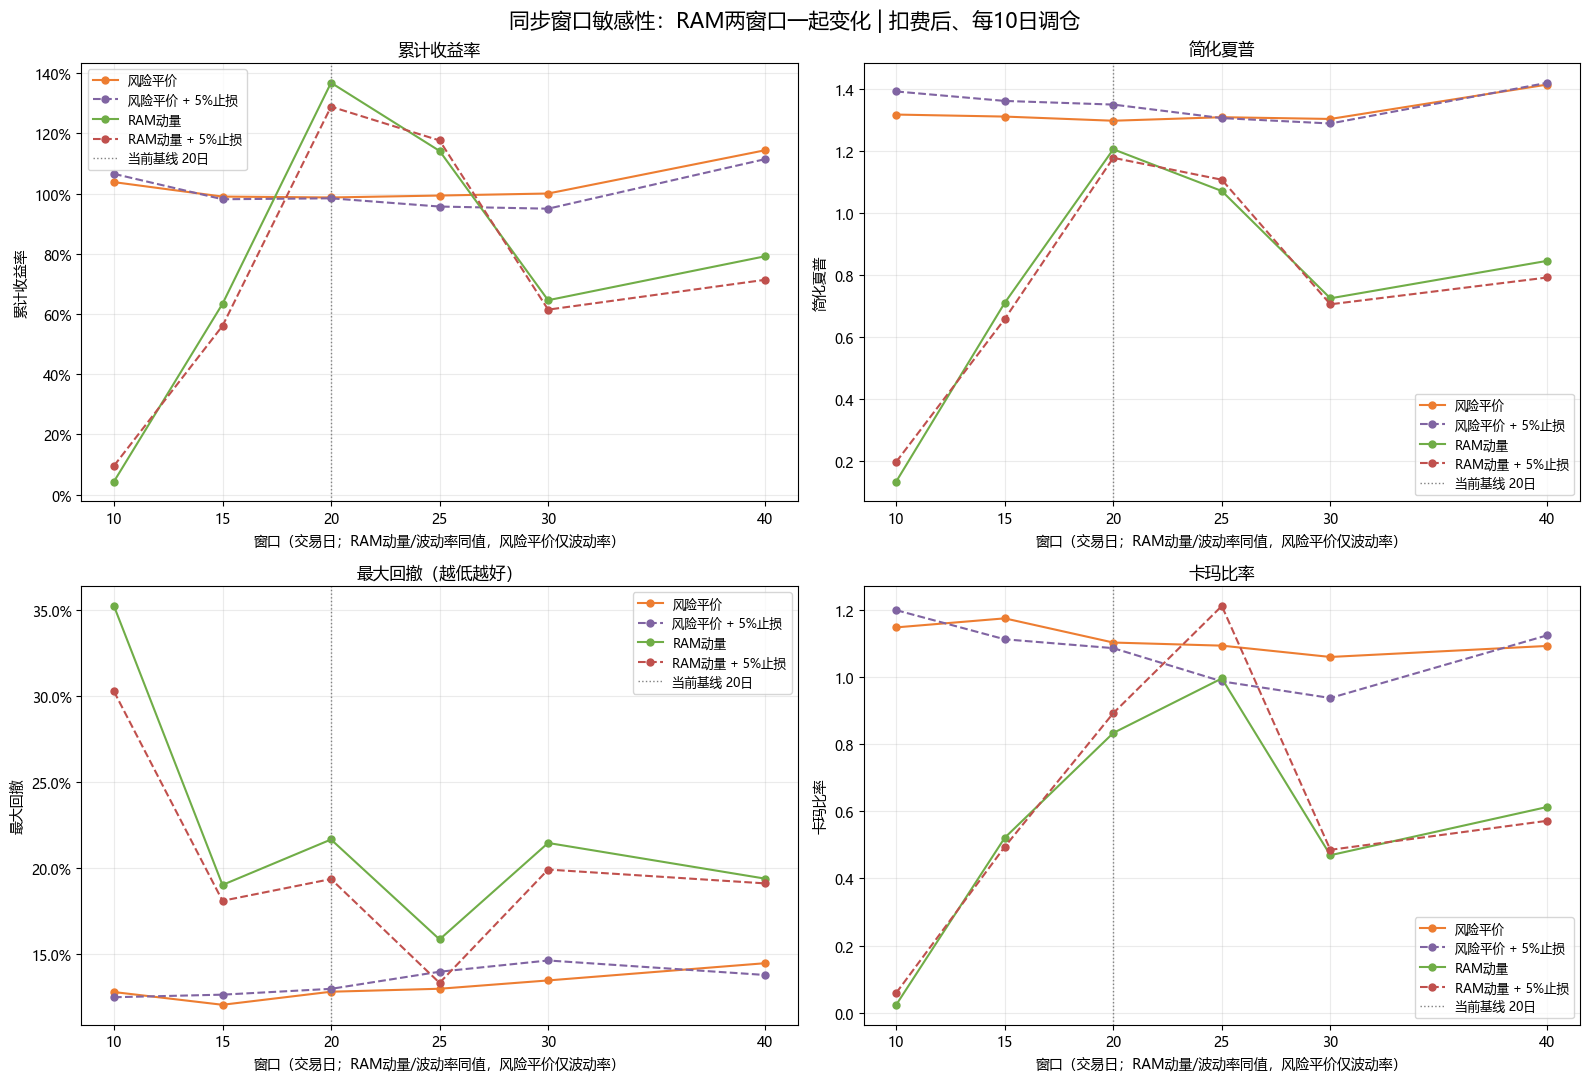

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for ax, metric in zip(axes.flat, SCAN_METRICS):
    for name in scan_specs:
        rows = sensitivity_results[sensitivity_results.strategy.eq(name)].sort_values("value")
        ax.plot(rows.value, rows[metric], marker="o", markersize=5,
                color=COLORS[name], linestyle="--" if "止损" in name else "-",
                linewidth=1.5, label=name)
    ax.axvline(PERIOD, color="gray", linestyle=":", linewidth=1,
               label=f"当前基线 {PERIOD}日")
    ax.set_xticks(SENSITIVITY_VALUES)
    ax.set_xlabel("窗口（交易日；RAM动量/波动率同值，风险平价仅波动率）")
    ax.set_ylabel(LABELS[metric])
    ax.set_title(LABELS[metric] + ("（越低越好）" if metric == "max_drawdown" else ""))
    if metric in {"cumulative_return", "max_drawdown"}:
        ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(alpha=.25)
    ax.legend(fontsize=9)
fig.suptitle(f"同步窗口敏感性：RAM两窗口一起变化 | 扣费后、每{REBALANCE_DAYS}日调仓", fontsize=15)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "08_sensitivity_synchronized_windows.png", dpi=150)
plt.show()
plt.close(fig)


In [18]:
from IPython.display import Markdown

# 分析由本次同步扫描结果生成，不沿用上次单因素扫描的结论。
summary_rows = []
for name, group in sensitivity_results.groupby("strategy", sort=False):
    baseline = group.loc[group.value.eq(PERIOD)].iloc[0]
    for metric in SCAN_METRICS:
        low, high = float(group[metric].min()), float(group[metric].max())
        optimum = low if metric == "max_drawdown" else high
        best_values = group.loc[np.isclose(group[metric], optimum, rtol=1e-10, atol=1e-12), "value"].tolist()
        summary_rows.append({
            "parameter": SCAN_PARAMETER, "strategy": name, "metric": metric,
            "baseline": float(baseline[metric]), "minimum": low, "maximum": high,
            "range": high - low, "best_value": optimum,
            "best_windows": ",".join(map(str, best_values)),
        })
sensitivity_summary = pd.DataFrame(summary_rows)
display(sensitivity_summary.drop(columns="parameter").assign(
    metric=lambda x: x.metric.map(LABELS)
).rename(columns={"strategy": "策略", "metric": "指标",
                  "baseline": "当前基线值", "minimum": "扫描最小值",
                  "maximum": "扫描最大值", "range": "跨度",
                  "best_value": "扫描最优值", "best_windows": "最优同步窗口（交易日）"}))

analysis_lines = [
    "### 同步窗口敏感性分析（由当前结果生成）",
    "RAM的动量和波动率窗口同时取扫描值；风险平价只使用波动率窗口。以下不是单因素扫描结论。",
]
below = [v for v in SENSITIVITY_VALUES if v < PERIOD]
above = [v for v in SENSITIVITY_VALUES if v > PERIOD]
neighbors = ([max(below)] if below else []) + [PERIOD] + ([min(above)] if above else [])
for name in scan_specs:
    rows = sensitivity_results[sensitivity_results.strategy.eq(name)].sort_values("value")
    best_sharpe = rows.loc[rows.simplified_sharpe.idxmax()]
    best_calmar = rows.loc[rows.calmar.idxmax()]
    best_return = rows.loc[rows.cumulative_return.idxmax()]
    min_dd = rows.loc[rows.max_drawdown.idxmin()]
    earliest, latest = rows.first_buy_date.min(), rows.first_buy_date.max()
    analysis_lines.append(
        f"- **{name}**：收益范围{rows.cumulative_return.min():.2%}—{rows.cumulative_return.max():.2%}；"
        f"最高收益窗口{int(best_return.value)}日；"
        f"最高夏普窗口{int(best_sharpe.value)}日（{best_sharpe.simplified_sharpe:.3f}）；"
        f"最低回撤窗口{int(min_dd.value)}日（{min_dd.max_drawdown:.2%}）；"
        f"最高卡玛窗口{int(best_calmar.value)}日（{best_calmar.calmar:.3f}）。"
        f"首次买入日期覆盖{earliest:%Y-%m-%d}至{latest:%Y-%m-%d}。")
    nearby = rows[rows.value.isin(neighbors)]
    detail = "；".join(
        f"{int(r.value)}日：收益{r.cumulative_return:.2%} / 夏普{r.simplified_sharpe:.3f} / 回撤{r.max_drawdown:.2%}"
        for r in nearby.itertuples())
    analysis_lines.append(f"  - 基线邻域：{detail}。")
analysis_lines.append("#### 止损的取舍")
for plain_name in ["风险平价", "RAM动量"]:
    protected_name = f"{plain_name} + {STOP_LOSS:.0%}止损"
    plain = sensitivity_results[sensitivity_results.strategy.eq(plain_name)].set_index("value")
    protected = sensitivity_results[sensitivity_results.strategy.eq(protected_name)].set_index("value")
    comparison = (protected[SCAN_METRICS] - plain[SCAN_METRICS]).sort_index()
    improvements = {
        metric: int(((comparison[metric] < -1e-12) if metric == "max_drawdown"
                     else (comparison[metric] > 1e-12)).sum())
        for metric in SCAN_METRICS
    }
    analysis_lines.append(
        f"- 对{plain_name}，加止损在{len(comparison)}个窗口中有"
        f"{improvements['max_drawdown']}个降低最大回撤、"
        f"{improvements['simplified_sharpe']}个提高夏普、"
        f"{improvements['cumulative_return']}个提高累计收益、"
        f"{improvements['calmar']}个提高卡玛；止损不保证所有指标同时改善。")
analysis_lines += [
    "#### 结论边界",
    "- 同步扫描反映两个窗口共同变化的整体敏感性，不能再归因于动量或波动率某一项单独变化。",
    f"- 结合当前{PERIOD}日附近结果判断是否形成平稳区间；收益、夏普、回撤、卡玛的最佳窗口可能不同。",
    "- 不使用区间开始前的数据；不同窗口的预热和RAM正动量过滤也会改变首次建仓日期。",
    "- 本次只检查动量窗口=波动率窗口的同值组合，不代表所有不等窗口组合中的联合最优。",
    "- 同一历史区间内选优仍属样本内诊断，不能替代时间切分或滚动样本外验证。原始默认参数不自动更改。",
]
display(Markdown("\n\n".join(analysis_lines)))


,策略,指标,当前基线值,扫描最小值,扫描最大值,跨度,扫描最优值,最优同步窗口（交易日）
0,风险平价,累计收益率,0.987257,0.987257,1.144139,0.156882,1.144139,40
1,风险平价,简化夏普,1.298936,1.298936,1.415919,0.116983,1.415919,40
2,风险平价,最大回撤,0.128093,0.120509,0.144656,0.024147,0.120509,15
3,风险平价,卡玛比率,1.102406,1.059455,1.174453,0.114998,1.174453,15
4,风险平价 + 5%止损,累计收益率,0.984430,0.949960,1.114610,0.164651,1.114610,40
5,风险平价 + 5%止损,简化夏普,1.351143,1.290062,1.421584,0.131523,1.421584,40
6,风险平价 + 5%止损,最大回撤,0.129772,0.124898,0.146239,0.021341,0.124898,10
7,风险平价 + 5%止损,卡玛比率,1.085736,0.937228,1.198883,0.261655,1.198883,10
8,RAM动量,累计收益率,1.368209,0.043725,1.368209,1.324485,1.368209,20
9,RAM动量,简化夏普,1.206750,0.133509,1.206750,1.073241,1.206750,20


### 同步窗口敏感性分析（由当前结果生成）

RAM的动量和波动率窗口同时取扫描值；风险平价只使用波动率窗口。以下不是单因素扫描结论。

- **风险平价**：收益范围98.73%—114.41%；最高收益窗口40日；最高夏普窗口40日（1.416）；最低回撤窗口15日（12.05%）；最高卡玛窗口15日（1.174）。首次买入日期覆盖2021-01-18至2021-03-08。

  - 基线邻域：15日：收益99.02% / 夏普1.312 / 回撤12.05%；20日：收益98.73% / 夏普1.299 / 回撤12.81%；25日：收益99.36% / 夏普1.310 / 回撤12.98%。

- **风险平价 + 5%止损**：收益范围95.00%—111.46%；最高收益窗口40日；最高夏普窗口40日（1.422）；最低回撤窗口10日（12.49%）；最高卡玛窗口10日（1.199）。首次买入日期覆盖2021-01-18至2021-03-08。

  - 基线邻域：15日：收益98.13% / 夏普1.363 / 回撤12.64%；20日：收益98.44% / 夏普1.351 / 回撤12.98%；25日：收益95.71% / 夏普1.307 / 回撤13.97%。

- **RAM动量**：收益范围4.37%—136.82%；最高收益窗口20日；最高夏普窗口20日（1.207）；最低回撤窗口25日（15.85%）；最高卡玛窗口25日（0.996）。首次买入日期覆盖2021-01-18至2021-03-22。

  - 基线邻域：15日：收益63.39% / 夏普0.711 / 回撤19.01%；20日：收益136.82% / 夏普1.207 / 回撤21.65%；25日：收益114.18% / 夏普1.072 / 回撤15.85%。

- **RAM动量 + 5%止损**：收益范围9.60%—128.89%；最高收益窗口20日；最高夏普窗口20日（1.179）；最低回撤窗口25日（13.32%）；最高卡玛窗口25日（1.211）。首次买入日期覆盖2021-01-18至2021-03-22。

  - 基线邻域：15日：收益56.07% / 夏普0.659 / 回撤18.09%；20日：收益128.89% / 夏普1.179 / 回撤19.35%；25日：收益117.66% / 夏普1.108 / 回撤13.32%。

#### 止损的取舍

- 对风险平价，加止损在6个窗口中有2个降低最大回撤、4个提高夏普、1个提高累计收益、2个提高卡玛；止损不保证所有指标同时改善。

- 对RAM动量，加止损在6个窗口中有6个降低最大回撤、2个提高夏普、2个提高累计收益、4个提高卡玛；止损不保证所有指标同时改善。

#### 结论边界

- 同步扫描反映两个窗口共同变化的整体敏感性，不能再归因于动量或波动率某一项单独变化。

- 结合当前20日附近结果判断是否形成平稳区间；收益、夏普、回撤、卡玛的最佳窗口可能不同。

- 不使用区间开始前的数据；不同窗口的预热和RAM正动量过滤也会改变首次建仓日期。

- 本次只检查动量窗口=波动率窗口的同值组合，不代表所有不等窗口组合中的联合最优。

- 同一历史区间内选优仍属样本内诊断，不能替代时间切分或滚动样本外验证。原始默认参数不自动更改。

In [19]:
sensitivity_results.to_csv(OUTPUT_DIR / "parameter_sensitivity.csv", index=False, encoding="utf-8-sig")
sensitivity_summary.to_csv(OUTPUT_DIR / "parameter_sensitivity_summary.csv", index=False, encoding="utf-8-sig")
metadata["parameter_sensitivity"] = {
    "values": SENSITIVITY_VALUES, "baseline_window": PERIOD,
    "design": "synchronized diagonal scan: RAM momentum_window = volatility_window = value; not full joint grid",
    "window_rule": {
        "ram": "momentum_window = volatility_window = value",
        "risk_parity": "volatility_window = value; momentum unused",
    },
    "strategies": list(scan_specs), "metrics": SCAN_METRICS,
    "row_count": len(sensitivity_results), "unique_effective_configurations": len(scan_cache),
    "new_backtests": new_scan_runs,
    "risk_parity_momentum": "unused, including warmup",
    "warmup": "current window + 1 prices; no pre-start data; no common warmup",
    "figure": "08_sensitivity_synchronized_windows.png",
}
(OUTPUT_DIR / "configuration.json").write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")
print("同步扫描结果、指标范围/最优点汇总、四指标折线图已保存：", OUTPUT_DIR)


同步扫描结果、指标范围/最优点汇总、四指标折线图已保存： D:\proj\xquant\xquant-learning-sxl\q5\results
